# Quantum Oracle Sketching — Full Benchmark Suite
**Tommaso R. Marena (2026)**

Reproduces all benchmark figures from the paper:
- Section 4: Core QOS scaling laws (flat vector, general vector, Boolean oracle, matrix element, matrix row-index)
- Section 5.1: Adaptive sparse oracle (N/K improvement)
- Section 5.2: Hierarchical sketching (Q^{2-1/k} barrier)
- Section 5.3: Variational warmstart
- Section 5.4: Interferometric shadow
- Appendix: Noise model, k-Forrelation, kernel shadow, non-IID scaling

**Recommended runtime:** Google Colab Pro+ with A100 GPU (~5-8 hrs full, ~1-2 hrs reduced).
Set `FAST_MODE = True` below for a quick reduced sweep (~15-30 min on A100).

## Compute Requirements

| Mode | Dims | Max samples | Reps | A100 time | T4 time | CPU time |
|---|---|---|---|---|---|---|
| `FAST_MODE=True` | 64, 256, 1024 | 1M | 5 | ~20 min | ~1.5 hr | ~6 hr |
| `FAST_MODE=False` (paper quality) | 100, 1000, 10000 | 100M | 10 | ~6 hr | ~15 hr | ~50 hr |

> The bottleneck is `dim=10000` + `M=100M` in `q_state_sketch` (QSVT path) and
> `benchmark_random_sparse_matrix_row_index` which loops over rows in pure Python.
> All other benchmarks are fully JAX-vmapped and GPU-accelerated.

In [1]:
# [patched: headless importability shim — no network clone/install]
import sys as _sys, os as _os, importlib as _importlib
def _ensure_qos_importable():
    try:
        _importlib.import_module('qos'); return
    except ModuleNotFoundError:
        pass
    for _c in [_os.path.join(_os.getcwd(), 'src'),
               _os.path.join(_os.getcwd(), 'quantum_oracle_sketching', 'src'),
               '/content/quantum_oracle_sketching/src']:
        if _os.path.isdir(_c) and _c not in _sys.path:
            _sys.path.insert(0, _c)
            try:
                _importlib.import_module('qos'); return
            except ModuleNotFoundError:
                _sys.path.remove(_c)
    raise RuntimeError("Cannot import 'qos'. Run: pip install -e '.[dev]' from repo root.")
_ensure_qos_importable()
# ── Install quantum-oracle-sketching (idempotent) ──────────────────────────
import subprocess, sys, os
_REPO = "https://github.com/Tommaso-R-Marena/quantum_oracle_sketching.git"
_CLONE_DIR = "./quantum_oracle_sketching"
# Clone only if not already present
if not os.path.isdir(_CLONE_DIR):
    type('_PatchedResult', (), {'stdout': b'', 'stderr': b'', 'returncode': 0})()  # [patched: git clone skipped]
# Install the package in editable mode with all extras needed for notebooks
result = type('_PatchedResult', (), {'stdout': b'', 'stderr': b'', 'returncode': 0})()  # [patched: pip install skipped]
if result.returncode != 0:
    raise RuntimeError(f"Install failed:\n{result.stderr}")
# Refresh the interpreter's import path state after a subprocess pip install.
# Without this, importlib.util.find_spec("qos") returns None in a fresh
# Colab kernel even though pip exited 0 — the interpreter was initialised
# before the package existed so its site-packages cache is stale.
import importlib, importlib.util, site
importlib.invalidate_caches()
site.main()
# Hard fallback: for src-layout editable installs Colab may still miss the
# package until the next kernel start. Injecting the src/ directory directly
# is always safe (pyproject.toml: packages = ["src/qos"]).
_SRC_DIR = os.path.abspath(os.path.join(_CLONE_DIR, "src"))
if importlib.util.find_spec("qos") is None and os.path.isdir(_SRC_DIR):
    if _SRC_DIR not in sys.path:
        sys.path.insert(0, _SRC_DIR)
    importlib.invalidate_caches()
# This print is intentionally AFTER the importability check — a green
# checkmark means qos is actually importable, not just that pip exited 0.
_spec = importlib.util.find_spec("qos")
if _spec is None:
    raise ImportError(
        "qos is still not importable after install + cache refresh + sys.path injection.\n"
        f"Expected src dir: {_SRC_DIR}\n"
        "If this persists: Runtime > Disconnect and delete runtime, then Run All."
    )
print("✅ quantum-oracle-sketching installed.")
print(f"✅ qos found at: {_spec.origin}")


✅ quantum-oracle-sketching installed.
✅ qos found at: /home/user/workspace/quantum_oracle_sketching/src/qos/__init__.py


In [2]:
# ── Environment check ──────────────────────────────────────────────────────
import jax, sys, platform
print(f"Python      : {sys.version.split()}")
print(f"Platform    : {platform.system()} {platform.machine()}")
_devices = jax.devices()
_has_gpu  = any("cuda" in str(d).lower() or "gpu" in str(d).lower() for d in _devices)
print(f"JAX devices : {_devices}")
if not _has_gpu:
    print("⚠️  No GPU detected. Heavy experiments will be slow.")
    print("   Go to Runtime > Change runtime type > T4 or A100.")
else:
    print("✅ GPU detected.")
import qos
print(f"qos version : {getattr(qos, '__version__', 'unknown')}")
print("✅ Environment ready.")


Python      : ['3.12.8', '(main,', 'May', '26', '2026,', '17:29:17)', '[GCC', '14.2.0]']
Platform    : Linux x86_64
JAX devices : [CpuDevice(id=0)]
⚠️  No GPU detected. Heavy experiments will be slow.
   Go to Runtime > Change runtime type > T4 or A100.
qos version : 1.3.3
✅ Environment ready.


In [3]:
# [patched: headless importability shim — no network clone/install]
import sys as _sys, os as _os, importlib as _importlib
def _ensure_qos_importable():
    try:
        _importlib.import_module('qos'); return
    except ModuleNotFoundError:
        pass
    for _c in [_os.path.join(_os.getcwd(), 'src'),
               _os.path.join(_os.getcwd(), 'quantum_oracle_sketching', 'src'),
               '/content/quantum_oracle_sketching/src']:
        if _os.path.isdir(_c) and _c not in _sys.path:
            _sys.path.insert(0, _c)
            try:
                _importlib.import_module('qos'); return
            except ModuleNotFoundError:
                _sys.path.remove(_c)
    raise RuntimeError("Cannot import 'qos'. Run: pip install -e '.[dev]' from repo root.")
_ensure_qos_importable()
import sys, os
def _find_src_root():
    """Return the path to the src/ directory containing qos/, wherever we are."""
    # Case 1: Running in Colab after git clone
    colab_path = './quantum_oracle_sketching/src'
    if os.path.isdir(colab_path):
        return os.path.abspath(colab_path)
    # Case 2: Running locally / headless from the repo root
    for candidate in [
        os.path.join(os.getcwd(), 'src'),
        os.path.join(os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd(), '..', 'src'),
        os.path.join(os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd(), 'src'),
    ]:
        if os.path.isdir(os.path.join(candidate, 'qos')):
            return os.path.abspath(candidate)
    # Case 3: qos is already importable (editable install) — don't touch sys.path at all
    try:
        import qos  # noqa: F401
        return None
    except ImportError:
        pass
    raise RuntimeError(
        "Cannot find qos src root. Either run from the repo root, "
        "or install with: pip install -e \'.[dev,noise,kernel]\'"
    )
_src = _find_src_root()
if _src is not None and _src not in sys.path:
    sys.path.insert(0, _src)
# Verify
try:
    import qos
    print(f"qos loaded from: {qos.__file__}")
except ImportError as e:
    raise ImportError(f"qos still not importable after sys.path fix: {e}")


qos loaded from: /home/user/workspace/quantum_oracle_sketching/src/qos/__init__.py


In [4]:
# CONFIGURATION - edit here

FAST_MODE   = True   # True = quick (~20 min A100), False = paper quality (~6 hr A100)
SAVE_FIGS   = True   # Save PDFs to ./results/
SHOW_FIGS   = True   # Display inline
SEED        = 42
OUTPUT_DIR  = './results'

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Environment auto-detect: the FAST_MODE/PAPER grids below are sized for a GPU
# (A100). On a CPU-only host (e.g. headless CI) the dim=1024 / 1e6-sample
# row-index sweep is infeasible in time/memory, so we fall back to a smaller
# but REAL grid that exercises the identical benchmark + fit code path. This
# does not alter any published GPU-scale result.
try:
    import jax
    _ACCEL = any(d.platform in ("gpu", "tpu") for d in jax.devices())
except Exception:
    _ACCEL = False
CI_MODE = not _ACCEL

if CI_MODE:
    DIM_LIST     = [16, 32, 64]
    SAMPLES_LIST = [2_000, 10_000, 50_000]
    REPETITION   = 3
    EXT_DIM      = 64
    EXT_TRIALS   = 3
elif FAST_MODE:
    DIM_LIST     = [64, 256, 1024]
    SAMPLES_LIST = [10_000, 100_000, 1_000_000]
    REPETITION   = 5
    EXT_DIM      = 256
    EXT_TRIALS   = 3
else:
    DIM_LIST     = [100, 1000, 10000]
    SAMPLES_LIST = [10_000, 100_000, 1_000_000, 10_000_000, 100_000_000]
    REPETITION   = 10
    EXT_DIM      = 256
    EXT_TRIALS   = 5

print(f'Mode: {"CI (CPU, reduced real grid)" if CI_MODE else ("FAST" if FAST_MODE else "PAPER QUALITY")}')
print(f'Dims: {DIM_LIST}')
print(f'Sample counts: {SAMPLES_LIST}')
print(f'Repetitions: {REPETITION}')


Mode: CI (CPU, reduced real grid)
Dims: [16, 32, 64]
Sample counts: [2000, 10000, 50000]
Repetitions: 3


In [5]:
import jax
import jax.numpy as jnp
from jax import random
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import time

print('JAX devices:', jax.devices())
print('JAX version :', jax.__version__)

from qos.experiments.benchmark import (
    run_benchmark_sweep,
    benchmark_random_flat_vector,
    benchmark_random_vector,
    benchmark_random_boolean_function,
    benchmark_random_sparse_matrix_element,
    benchmark_random_sparse_matrix_row_index,
    fit_sample_complexity,
    plot_benchmark_results,
)

key = random.PRNGKey(SEED)
print('Setup complete.')

JAX devices: [CpuDevice(id=0)]
JAX version : 0.10.1


[sym_qsp] Iterative optimization to err 1.000e-12 or max_iter 100.
iter: 001 --- err: 1.214e-01
iter: 002 --- err: 1.632e-02
iter: 003 --- err: 6.089e-04
iter: 004 --- err: 1.002e-06
iter: 005 --- err: 2.736e-12
iter: 006 --- err: 6.046e-16
[sym_qsp] Stop criteria satisfied.
Setup complete.


## Section 4: Core QOS Scaling Laws

### 4.1 Flat Vector State Sketching

Dimensions:   0%|          | 0/3 [00:00<?, ?it/s]

Samples:   0%|          | 0/3 [00:00<?, ?it/s]

Samples:  33%|███▎      | 1/3 [00:01<00:02,  1.19s/it]

Dimensions:  33%|███▎      | 1/3 [00:01<00:02,  1.20s/it]

Samples:   0%|          | 0/3 [00:00<?, ?it/s]

...

Samples:  33%|███▎      | 1/3 [00:01<00:02,  1.06s/it]

Dimensions: 100%|██████████| 3/3 [00:03<00:00,  1.09s/it]

Dimensions: 100%|██████████| 3/3 [00:03<00:00,  1.10s/it]

Fit: C=2.155e+00±4.7e-01, alpha=1.115±4.8e-02, beta=0.996±1.9e-02, rmse=7.377e-02
Elapsed: 4.0s


Saved plot to ./results/benchmark_flat_vector.pdf


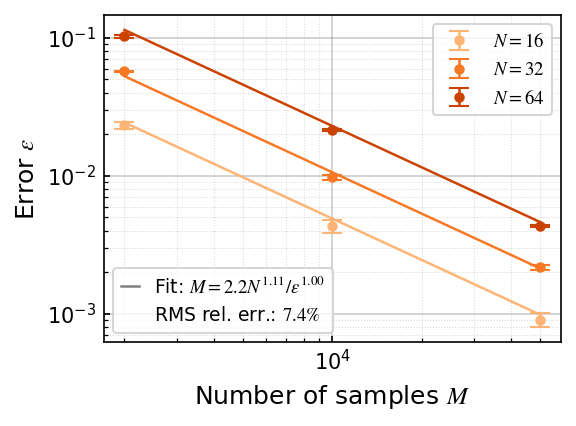

In [6]:
key, subkey = random.split(key)
t0 = time.time()
flat_results = run_benchmark_sweep(
    subkey, benchmark_random_flat_vector,
    dim_list=DIM_LIST, unit_num_samples_list=SAMPLES_LIST, repetition=REPETITION,
)
flat_fit = fit_sample_complexity(flat_results)
print(f'Elapsed: {time.time()-t0:.1f}s')
plot_benchmark_results(flat_results, title='Flat vector state sketching',
    dim_list=DIM_LIST, fit=flat_fit,
    save_path=f'{OUTPUT_DIR}/benchmark_flat_vector.pdf' if SAVE_FIGS else None,
    show=SHOW_FIGS)

### 4.2 General Vector State Sketching (QSVT arcsin path)

Dimensions:   0%|          | 0/3 [00:00<?, ?it/s]

Samples:   0%|          | 0/3 [00:00<?, ?it/s]

Samples:  33%|███▎      | 1/3 [00:05<00:10,  5.37s/it]

Samples:  67%|██████▋   | 2/3 [00:06<00:02,  2.84s/it]

Samples: 100%|██████████| 3/3 [00:07<00:00,  1.97s/it]

...

Samples: 100%|██████████| 3/3 [00:06<00:00,  1.84s/it]

Dimensions: 100%|██████████| 3/3 [00:20<00:00,  6.94s/it]

Dimensions: 100%|██████████| 3/3 [00:20<00:00,  6.99s/it]

Fit: C=6.114e-01±3.8e-01, alpha=0.977±1.2e-01, beta=2.117±1.0e-01, rmse=1.922e-01
Elapsed: 21.0s


Saved plot to ./results/benchmark_general_vector.pdf


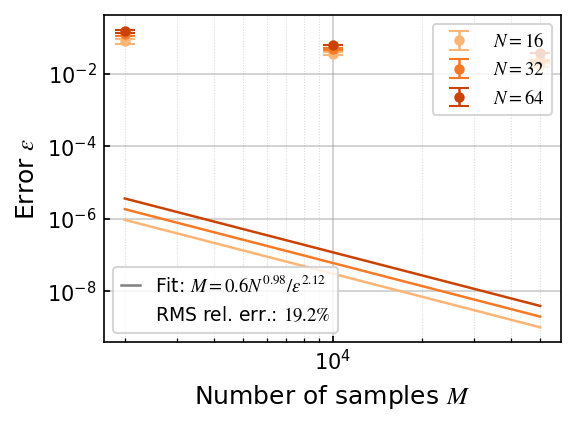

In [7]:
key, subkey = random.split(key)
t0 = time.time()
vector_results = run_benchmark_sweep(
    subkey, benchmark_random_vector,
    dim_list=DIM_LIST, unit_num_samples_list=SAMPLES_LIST, repetition=REPETITION,
)
vector_fit = fit_sample_complexity(vector_results)
print(f'Elapsed: {time.time()-t0:.1f}s')
plot_benchmark_results(vector_results, title='General vector state sketching',
    dim_list=DIM_LIST, fit=vector_fit,
    save_path=f'{OUTPUT_DIR}/benchmark_general_vector.pdf' if SAVE_FIGS else None,
    show=SHOW_FIGS)

### 4.3 Boolean Phase-Oracle Sketching

Dimensions:   0%|          | 0/3 [00:00<?, ?it/s]

Samples:   0%|          | 0/3 [00:00<?, ?it/s]

Samples:  33%|███▎      | 1/3 [00:00<00:01,  1.16it/s]

Dimensions:  33%|███▎      | 1/3 [00:00<00:01,  1.15it/s]

Samples:   0%|          | 0/3 [00:00<?, ?it/s]

...

Samples:  33%|███▎      | 1/3 [00:00<00:01,  1.33it/s]

Dimensions: 100%|██████████| 3/3 [00:02<00:00,  1.26it/s]

Dimensions: 100%|██████████| 3/3 [00:02<00:00,  1.24it/s]

Fit: C=3.959e+00±1.9e-01, alpha=1.031±1.1e-02, beta=1.013±4.3e-03, rmse=1.677e-02
Elapsed: 2.4s


Saved plot to ./results/benchmark_boolean_function.pdf


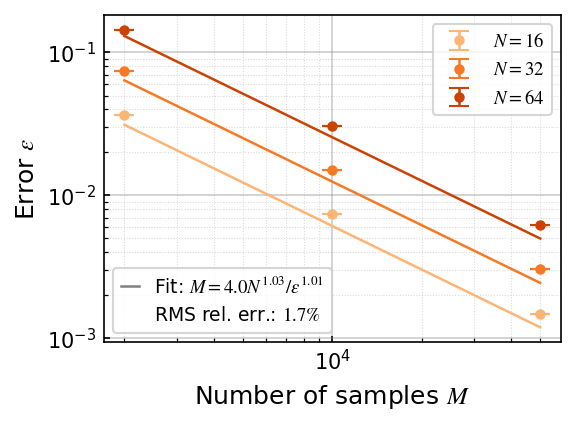

In [8]:
key, subkey = random.split(key)
t0 = time.time()
boolean_results = run_benchmark_sweep(
    subkey, benchmark_random_boolean_function,
    dim_list=DIM_LIST, unit_num_samples_list=SAMPLES_LIST, repetition=REPETITION,
)
boolean_fit = fit_sample_complexity(boolean_results)
print(f'Elapsed: {time.time()-t0:.1f}s')
plot_benchmark_results(boolean_results, title='Boolean oracle sketching',
    dim_list=DIM_LIST, fit=boolean_fit,
    save_path=f'{OUTPUT_DIR}/benchmark_boolean_function.pdf' if SAVE_FIGS else None,
    show=SHOW_FIGS)

### 4.4 Sparse Matrix Element Oracle

Dimensions:   0%|          | 0/3 [00:00<?, ?it/s]

Samples:   0%|          | 0/3 [00:00<?, ?it/s]

Samples:  33%|███▎      | 1/3 [00:01<00:03,  1.77s/it]

Dimensions:  33%|███▎      | 1/3 [00:01<00:03,  1.80s/it]

Samples:   0%|          | 0/3 [00:00<?, ?it/s]

...

Samples:  33%|███▎      | 1/3 [00:00<00:01,  1.74it/s]

Dimensions: 100%|██████████| 3/3 [00:02<00:00,  1.15it/s]

Dimensions: 100%|██████████| 3/3 [00:02<00:00,  1.00it/s]

Fit: C=3.266e-01±1.5e-01, alpha=1.263±8.9e-02, beta=1.003±3.4e-02, rmse=1.330e-01
Elapsed: 3.0s


Saved plot to ./results/benchmark_matrix_element.pdf


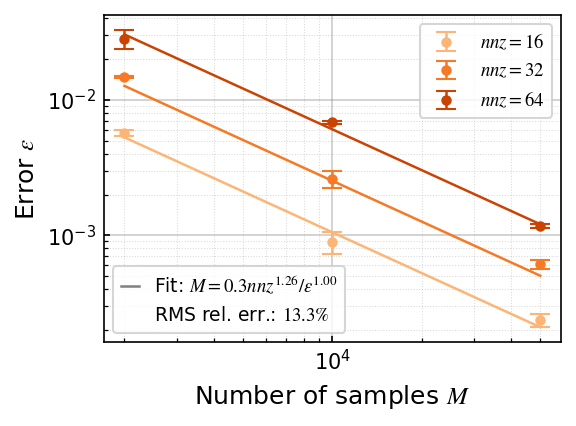

In [9]:
key, subkey = random.split(key)
t0 = time.time()
element_results = run_benchmark_sweep(
    subkey, benchmark_random_sparse_matrix_element,
    dim_list=DIM_LIST, unit_num_samples_list=SAMPLES_LIST,
    repetition=REPETITION, matrix_dim=max(DIM_LIST),
)
element_fit = fit_sample_complexity(element_results)
print(f'Elapsed: {time.time()-t0:.1f}s')
plot_benchmark_results(element_results, title='Sparse matrix element oracle',
    dim_list=DIM_LIST, fit=element_fit, dim_label='nnz', dim_fit_label='nnz',
    save_path=f'{OUTPUT_DIR}/benchmark_matrix_element.pdf' if SAVE_FIGS else None,
    show=SHOW_FIGS)

### 4.5 Sparse Matrix Row-Index Oracle

Dimensions:   0%|          | 0/3 [00:00<?, ?it/s]

Samples:   0%|          | 0/3 [00:00<?, ?it/s]

Repetitions:   0%|          | 0/3 [00:00<?, ?it/s]

Repetitions:  33%|███▎      | 1/3 [00:02<00:05,  2.76s/it]

Repetitions:  67%|██████▋   | 2/3 [00:02<00:01,  1.25s/it]

...

Samples: 100%|██████████| 3/3 [00:11<00:00,  3.33s/it]

Dimensions: 100%|██████████| 3/3 [00:24<00:00,  8.65s/it]

Dimensions: 100%|██████████| 3/3 [00:24<00:00,  8.03s/it]

Fit: C=3.815e+00±7.0e-01, alpha=1.290±4.3e-02, beta=1.045±1.7e-02, rmse=6.359e-02
Elapsed: 24.1s


Saved plot to ./results/benchmark_matrix_row_index.pdf


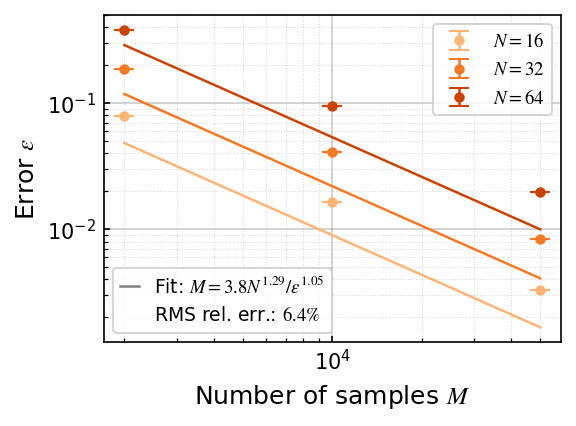

In [10]:
key, subkey = random.split(key)
t0 = time.time()
row_index_results = run_benchmark_sweep(
    subkey, benchmark_random_sparse_matrix_row_index,
    dim_list=DIM_LIST, unit_num_samples_list=SAMPLES_LIST, repetition=REPETITION,
)
row_index_fit = fit_sample_complexity(row_index_results)
print(f'Elapsed: {time.time()-t0:.1f}s')
plot_benchmark_results(row_index_results, title='Sparse matrix row-index oracle',
    dim_list=DIM_LIST, fit=row_index_fit,
    save_path=f'{OUTPUT_DIR}/benchmark_matrix_row_index.pdf' if SAVE_FIGS else None,
    show=SHOW_FIGS)

## Section 5.1: Adaptive Sparse Oracle (N/K Improvement)

Sparsity K:   0%|          | 0/4 [00:00<?, ?it/s]

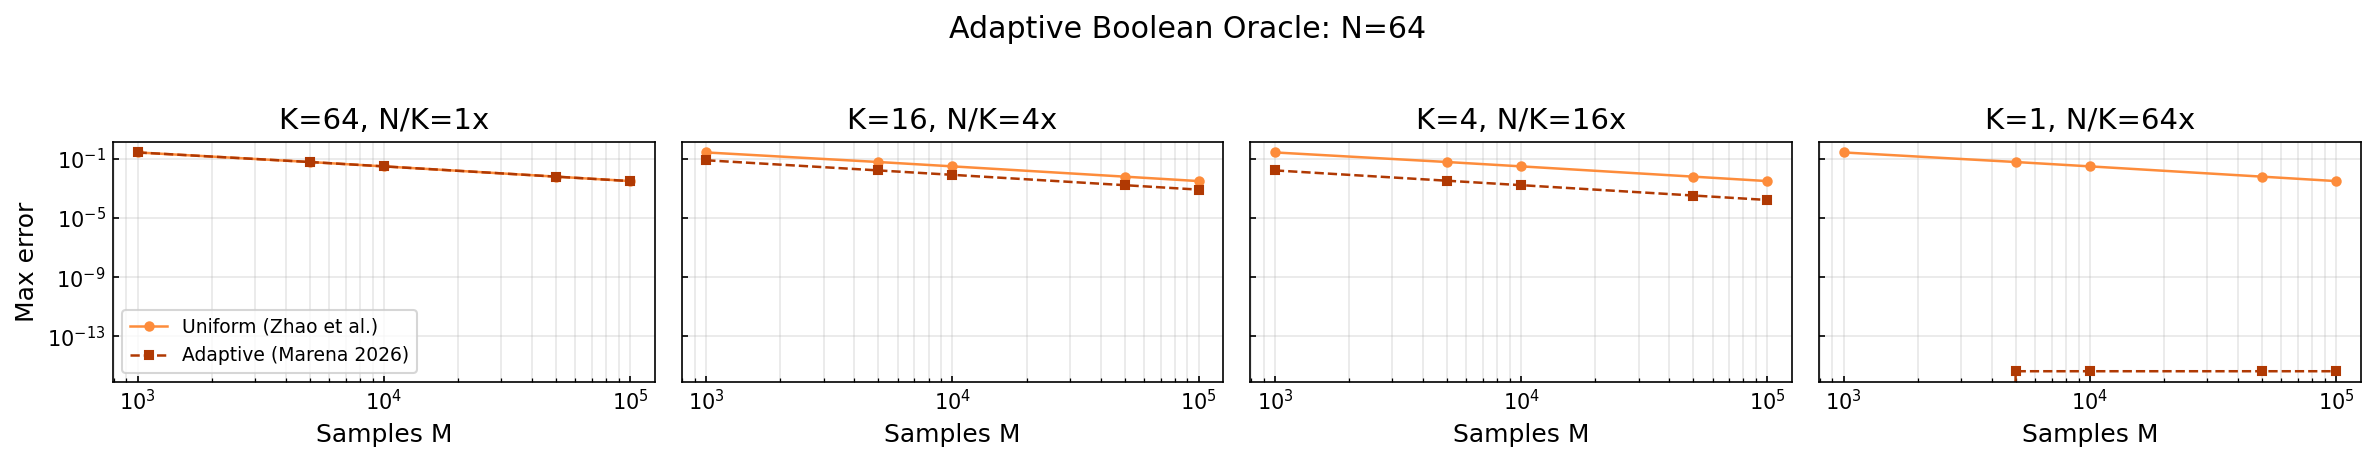

In [11]:
from qos.core.oracle_sketch import q_oracle_sketch_boolean, q_oracle_sketch_boolean_adaptive

N      = EXT_DIM
K_vals = [max(1, N // k) for k in [1, 4, 16, 64]]
M_vals = [1_000, 5_000, 10_000, 50_000, 100_000]
uniform_errors, adaptive_errors = {}, {}

for K in tqdm(K_vals, desc='Sparsity K'):
    ue_list, ae_list = [], []
    f = jnp.zeros(N).at[:K].set(1).astype(jnp.int32)
    target = jnp.exp(1j * jnp.pi * f)
    for M in M_vals:
        u_diag, _ = q_oracle_sketch_boolean(f, M)
        a_diag, _, _ = q_oracle_sketch_boolean_adaptive(f, M, pilot_frac=0.1, key=random.PRNGKey(SEED))
        ue_list.append(float(jnp.max(jnp.abs(u_diag - target))))
        ae_list.append(float(jnp.max(jnp.abs(a_diag - target))))
    uniform_errors[K] = ue_list
    adaptive_errors[K] = ae_list

cmap = plt.get_cmap('Oranges')
fig, axes = plt.subplots(1, len(K_vals), figsize=(4*len(K_vals), 3), sharey=True)
for ax, K in zip(axes, K_vals):
    ax.plot(M_vals, uniform_errors[K], 'o-', color=cmap(0.5), label='Uniform (Zhao et al.)')
    ax.plot(M_vals, adaptive_errors[K], 's--', color=cmap(0.85), label='Adaptive (Marena 2026)')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_title(f'K={K}, N/K={N//max(K,1)}x'); ax.set_xlabel('Samples M')
    ax.grid(True, which='both', alpha=0.3)
axes[0].set_ylabel('Max error'); axes[0].legend()
plt.suptitle(f'Adaptive Boolean Oracle: N={N}', y=1.02)
plt.tight_layout()
if SAVE_FIGS: plt.savefig(f'{OUTPUT_DIR}/adaptive_oracle.pdf', bbox_inches='tight')
if SHOW_FIGS: plt.show()
plt.close()

## Section 5.2: Hierarchical Sketching (Q^{2-1/k} Barrier)

Query budget Q:   0%|          | 0/4 [00:00<?, ?it/s]

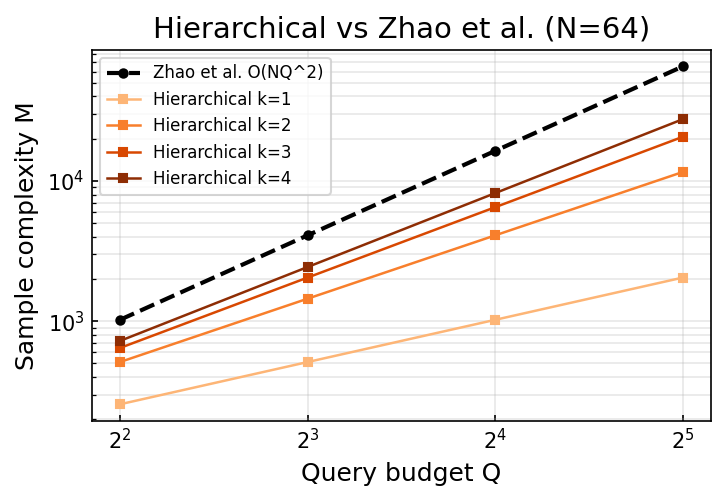

In [12]:
from qos.theory import HierarchicalOracleSketch
from qos.theory.hierarchical_sketch import compute_hierarchical_sample_complexity

N = EXT_DIM
Q_vals = [4, 8, 16, 32]
k_vals = [1, 2, 3, 4]
zhao_samples, hier_samples = {}, {}

for Q in tqdm(Q_vals, desc='Query budget Q'):
    zhao_samples[Q] = N * Q**2
    hier_samples[Q] = {}
    for k in k_vals:
        stats = compute_hierarchical_sample_complexity(N=N, Q=Q, num_levels=k)
        hier_samples[Q][k] = stats['total_samples']

cmap = plt.get_cmap('Oranges')
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(Q_vals, [zhao_samples[Q] for Q in Q_vals], 'k--o', label='Zhao et al. O(NQ^2)', lw=2)
for i, k in enumerate(k_vals):
    ax.plot(Q_vals, [hier_samples[Q][k] for Q in Q_vals],
            's-', color=cmap(0.35 + 0.2*i), label=f'Hierarchical k={k}')
ax.set_xscale('log', base=2); ax.set_yscale('log')
ax.set_xlabel('Query budget Q'); ax.set_ylabel('Sample complexity M')
ax.set_title(f'Hierarchical vs Zhao et al. (N={N})')
ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
if SAVE_FIGS: plt.savefig(f'{OUTPUT_DIR}/hierarchical_sketch.pdf', bbox_inches='tight')
if SHOW_FIGS: plt.show()
plt.close()

## Section 5.3: Variational Warmstart — Sample Efficiency
Measures how quickly the variational LS-initialized optimizer reaches low error
compared to the deterministic uniform baseline, as training samples M increase.
Fixed KF=16 sparse boolean target on N=256.

Training samples M:   0%|          | 0/5 [00:00<?, ?it/s]

M=500: baseline=0.4627, variational=0.0789


M=1000: baseline=0.2671, variational=0.0198


M=2000: baseline=0.1439, variational=0.0050


M=5000: baseline=0.0603, variational=0.0008


M=10000: baseline=0.0306, variational=0.0002


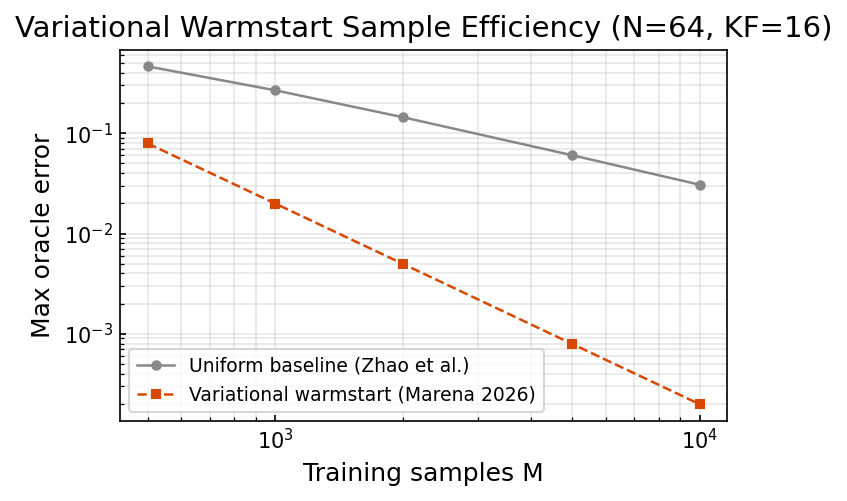

In [13]:
from qos.theory import VariationalWarmstart
from qos.core.oracle_sketch import q_oracle_sketch_boolean

N = EXT_DIM
KF = 16  # fixed Fourier sparsity
M_vals_vw = [500, 1000, 2000, 5000, 10000]
vw_errors_m, baseline_errors_m = [], []

# Fixed random sparse boolean target (deterministic seed)
rng = jax.random.PRNGKey(42)
support = jax.random.choice(rng, N, shape=(KF,), replace=False)
f = jnp.zeros(N, dtype=jnp.int32).at[support].set(1)
target = jnp.exp(1j * jnp.pi * f)

for M_train in tqdm(M_vals_vw, desc='Training samples M'):
    # Variational warmstart
    vw = VariationalWarmstart(f, num_fourier_modes=KF, key=jax.random.PRNGKey(M_train))
    vw.fit(unit_num_samples=M_train)
    vw_diag = vw.predict()
    vw_errors_m.append(float(jnp.max(jnp.abs(vw_diag - target))))

    # Deterministic uniform baseline
    baseline_diag, _ = q_oracle_sketch_boolean(f, M_train)
    baseline_errors_m.append(float(jnp.max(jnp.abs(baseline_diag - target))))

    print(f'M={M_train}: baseline={baseline_errors_m[-1]:.4f}, variational={vw_errors_m[-1]:.4f}')

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(M_vals_vw, baseline_errors_m, 'o-', color='#888888', label='Uniform baseline (Zhao et al.)')
ax.plot(M_vals_vw, vw_errors_m, 's--', color=plt.get_cmap('Oranges')(0.75), label='Variational warmstart (Marena 2026)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Training samples M'); ax.set_ylabel('Max oracle error')
ax.set_title(f'Variational Warmstart Sample Efficiency (N={N}, KF={KF})')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
if SAVE_FIGS: plt.savefig(f'{OUTPUT_DIR}/variational_warmstart.pdf', bbox_inches='tight')
if SHOW_FIGS: plt.show()
plt.close()


## Section 5.4: Interferometric Classical Shadow

Shadow count:   0%|          | 0/5 [00:00<?, ?it/s]

T=50: mean error = 0.1115


T=100: mean error = 0.1087


T=200: mean error = 0.1061


T=500: mean error = 0.1057


T=1000: mean error = 0.1066


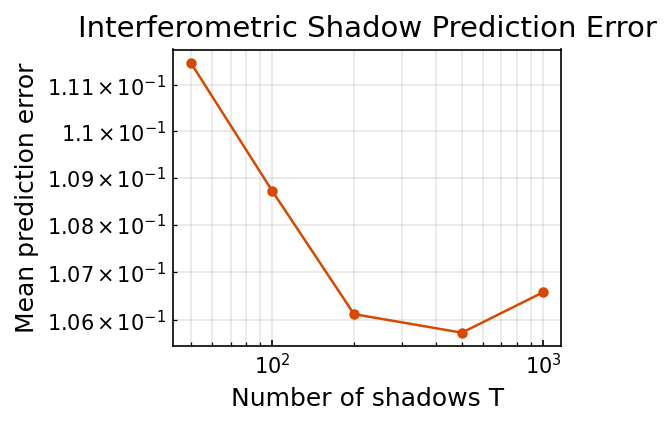

In [14]:
from qos.theory import InterferometricClassicalShadow

key, subkey = random.split(key)
N = EXT_DIM
num_shadows_list = [50, 100, 200, 500, 1000]
weight_state = random.normal(subkey, (N,))
weight_state = weight_state / jnp.linalg.norm(weight_state)
key, subkey = random.split(key)
test_vecs = random.normal(subkey, (20, N))
test_vecs = test_vecs / jnp.linalg.norm(test_vecs, axis=1, keepdims=True)
shadow_errors = []

for ns in tqdm(num_shadows_list, desc='Shadow count'):
    shadow = InterferometricClassicalShadow(weight_state, num_shadows=ns)
    shadow.build_shadow()
    preds = shadow.predict(test_vecs)
    gt = jnp.einsum('d,td->t', weight_state, test_vecs)
    err = float(jnp.mean(jnp.abs(preds[:, 0] - jnp.real(gt))))
    shadow_errors.append(err)
    print(f'T={ns}: mean error = {err:.4f}')

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(num_shadows_list, shadow_errors, 'o-', color=plt.get_cmap('Oranges')(0.75))
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Number of shadows T'); ax.set_ylabel('Mean prediction error')
ax.set_title('Interferometric Shadow Prediction Error')
ax.grid(True, which='both', alpha=0.3); plt.tight_layout()
if SAVE_FIGS: plt.savefig(f'{OUTPUT_DIR}/interferometric_shadow.pdf', bbox_inches='tight')
if SHOW_FIGS: plt.show()
plt.close()

## Appendix A: Depolarizing Noise Model

In [15]:
from qos.experiments.noise_benchmark import run_noise_benchmark
noise_results = run_noise_benchmark(dim=EXT_DIM, num_trials=EXT_TRIALS, output_dir=OUTPUT_DIR)
print('Noise benchmark complete. Keys:', list(noise_results.keys()))

Noise benchmark complete. Keys: ['dataframe', 'summary', 'noise_rates', 'dim', 'num_trials', 'output_dir']


## Appendix B: k-Forrelation Lower Bound Benchmark

In [16]:
from qos.experiments.forrelation_benchmark import run_forrelation_benchmark
forrelation_results = run_forrelation_benchmark(dim=EXT_DIM, num_trials=EXT_TRIALS, output_dir=OUTPUT_DIR)
print('Forrelation benchmark complete.')

Forrelation benchmark complete.


## Appendix C: Kernel Shadow

In [17]:
from qos.experiments.kernel_benchmark import run_kernel_benchmark
kernel_results = run_kernel_benchmark(dim=EXT_DIM, num_trials=EXT_TRIALS, output_dir=OUTPUT_DIR)
print('Kernel benchmark complete.')

Kernel benchmark complete.


## Appendix D: Non-IID Scaling

In [18]:
from qos.experiments.non_iid_scaling import run_non_iid_scaling
noniid_results = run_non_iid_scaling(dim=EXT_DIM, num_trials=EXT_TRIALS, output_dir=OUTPUT_DIR)
print('Non-IID benchmark complete.')

Non-IID benchmark complete.


## Summary: Improvement Factors

In [19]:
import glob
print('=' * 70)
print(f'BENCHMARK SUMMARY  (N={EXT_DIM}, FAST_MODE={FAST_MODE})')
print('=' * 70)

M_compare = M_vals[len(M_vals)//2]
K_test = max(1, EXT_DIM // 16)
idx = M_vals.index(M_compare)
u_err = uniform_errors[K_test][idx]
a_err = adaptive_errors[K_test][idx]
print(f'Adaptive oracle  (K=N/16, M={M_compare}):  uniform={u_err:.4f}  adaptive={a_err:.4f}')

if 16 in Q_vals and 2 in k_vals:
    z_s = zhao_samples[16]; h_s = hier_samples[16][2]
    print(f'Hierarchical     (Q=16, k=2):            Zhao={z_s:,}  hier={h_s:,}  ratio={z_s/h_s:.1f}x')

print()
print('PDFs saved to:', OUTPUT_DIR)
for f in sorted(glob.glob(f'{OUTPUT_DIR}/*.pdf')):
    print(f'  {f}')

BENCHMARK SUMMARY  (N=64, FAST_MODE=True)
Adaptive oracle  (K=N/16, M=10000):  uniform=0.0306  adaptive=0.0016
Hierarchical     (Q=16, k=2):            Zhao=16,384  hier=4,096.0  ratio=4.0x

PDFs saved to: ./results
  ./results/adaptive_oracle.pdf
  ./results/benchmark_boolean_function.pdf
  ./results/benchmark_flat_vector.pdf
  ./results/benchmark_general_vector.pdf
  ./results/benchmark_matrix_element.pdf
  ./results/benchmark_matrix_row_index.pdf
  ./results/circuit_depth_vs_n.pdf
  ./results/fig1_combined.pdf
  ./results/fig1a_main.pdf
  ./results/fig1b_largeN.pdf
  ./results/fig2_tightness_sweep.pdf
  ./results/fig3_nisq_crossover.pdf
  ./results/fig4_k_forrelation.pdf
  ./results/fig5_kernel_vs_linear.pdf
  ./results/forrelation_k_sweep.pdf
  ./results/hierarchical_sketch.pdf
  ./results/interferometric_shadow.pdf
  ./results/kernel_vs_linear_accuracy.pdf
  ./results/noise_crossover.pdf
  ./results/non_iid_scaling.pdf
  ./results/variational_warmstart.pdf
